In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
print("TensorFlow version:", tf.__version__)

gpu = tf.config.list_physical_devices('GPU')

if gpu:
    print("GPU detected:", gpu)
else:
    print("No GPU detected. Training will use CPU.")

TensorFlow version: 2.21.0
No GPU detected. Training will use CPU.


In [4]:
DATASET_PATH = "DR_working"

print(os.listdir(DATASET_PATH))

['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']


In [5]:
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        print(f"{folder}: {count}")

Healthy: 1000
Mild DR: 370
Moderate DR: 900
Proliferate DR: 290
Severe DR: 190


In [6]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 2750 files belonging to 5 classes.
Using 2200 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 2750 files belonging to 5 classes.
Using 550 files for validation.


In [9]:
class_names = train_ds.class_names

print("TensorFlow class order:")

for i, class_name in enumerate(class_names):
    print(i, "->", class_name)

TensorFlow class order:
0 -> Healthy
1 -> Mild DR
2 -> Moderate DR
3 -> Proliferate DR
4 -> Severe DR


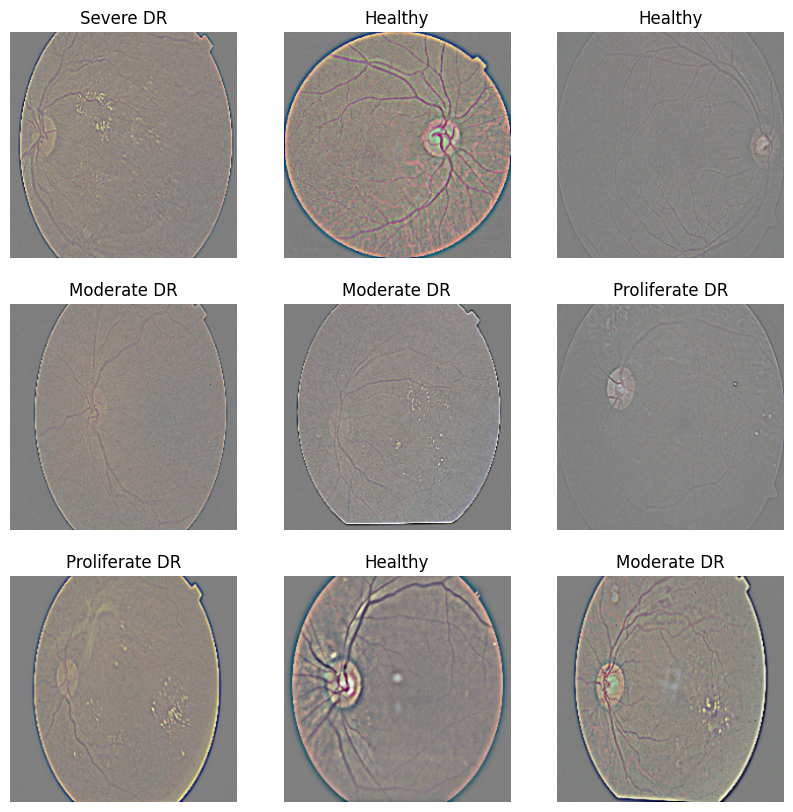

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = np.argmax(labels[i].numpy())

        plt.title(class_names[label_index])

        plt.axis("off")

plt.show()

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [13]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [14]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

model = models.Model(
    inputs,
    outputs
)

In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [17]:
class_counts = {}

for i, class_name in enumerate(class_names):

    folder_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    count = len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ])

    class_counts[i] = count

print(class_counts)

{0: 1000, 1: 370, 2: 900, 3: 290, 4: 190}


In [18]:
total_images = sum(class_counts.values())
number_of_classes = len(class_counts)

class_weights = {}

for class_index, count in class_counts.items():

    class_weights[class_index] = (
        total_images /
        (number_of_classes * count)
    )

print("Class weights:")

for i, weight in class_weights.items():
    print(
        class_names[i],
        ":",
        round(weight, 3)
    )

Class weights:
Healthy : 0.55
Mild DR : 1.486
Moderate DR : 0.611
Proliferate DR : 1.897
Severe DR : 2.895


In [19]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_dr_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [20]:
history = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=20,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/20


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.4836 - loss: 1.3110
Epoch 1: val_accuracy improved from None to 0.49818, saving model to best_dr_model.keras

Epoch 1: finished saving model to best_dr_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 78s 964ms/step - accuracy: 0.4836 - loss: 1.3110 - val_accuracy: 0.4982 - val_loss: 1.0407 - learning_rate: 0.0010
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.5641 - loss: 1.1211
Epoch 2: val_accuracy improved from 0.49818 to 0.65091, saving model to best_dr_model.keras

Epoch 2: finished saving model to best_dr_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 62s 895ms/step - accuracy: 0.5641 - loss: 1.1211 - val_accuracy: 0.6509 - val_loss: 0.8887 - learning_rate: 0.0010
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.6005 - loss: 1.0554
Epoch 3: val_accuracy did not improve from 0.65091
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 873ms/step - accuracy: 0.6005 - loss: 1.0554 - val_accuracy: 0.6218 - val_loss: 0.8910 - learnin

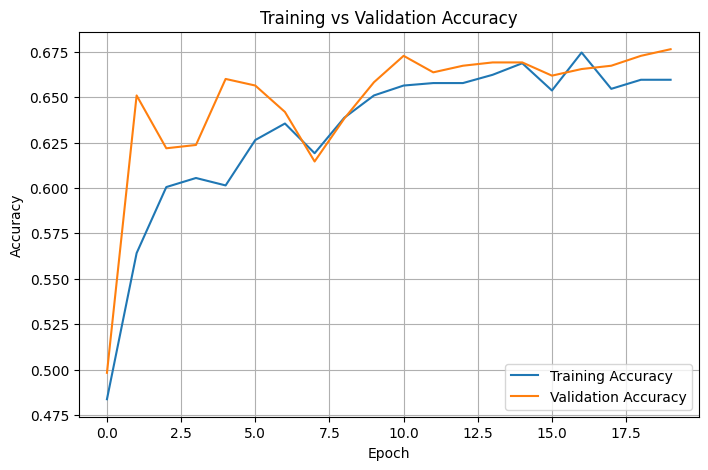

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

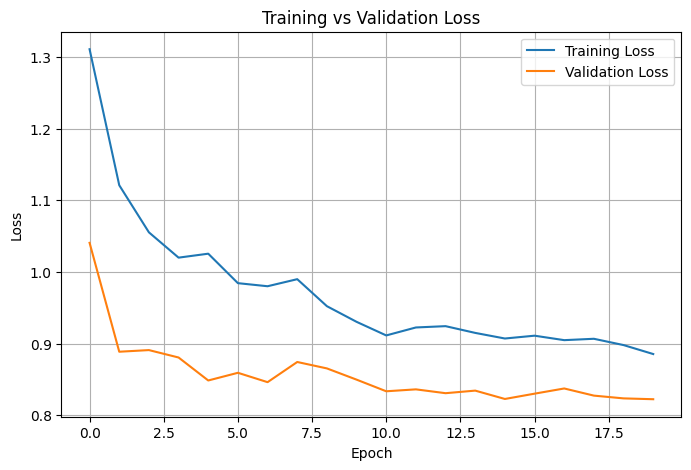

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [23]:
val_loss, val_accuracy = model.evaluate(
    val_ds
)

print(
    "Validation Loss:",
    round(val_loss, 4)
)

print(
    "Validation Accuracy:",
    round(val_accuracy * 100, 2),
    "%"
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 695ms/step - accuracy: 0.6764 - loss: 0.8225
Validation Loss: 0.8225
Validation Accuracy: 67.64 %


In [24]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    actual_classes = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_pred.extend(predicted_classes)
    y_true.extend(actual_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [25]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                precision    recall  f1-score   support

       Healthy     0.9250    0.9737    0.9487       190
       Mild DR     0.6522    0.5696    0.6081        79
   Moderate DR     0.6141    0.6457    0.6295       175
Proliferate DR     0.3750    0.1053    0.1644        57
     Severe DR     0.2840    0.4694    0.3538        49

      accuracy                         0.6764       550
     macro avg     0.5701    0.5527    0.5409       550
  weighted avg     0.6728    0.6764    0.6639       550



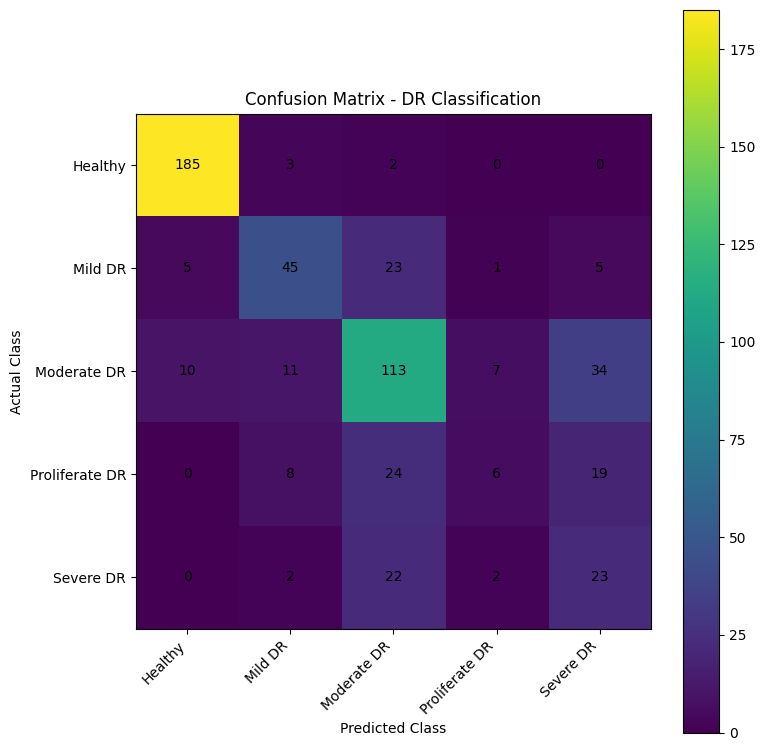

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 8))

plt.imshow(cm)

plt.title(
    "Confusion Matrix - DR Classification"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

In [27]:
healthy_idx = class_names.index("Healthy")
mild_idx = class_names.index("Mild DR")
moderate_idx = class_names.index("Moderate DR")
severe_idx = class_names.index("Severe DR")
proliferative_idx = class_names.index(
    "Proliferate DR"
)

In [28]:
referable_classes = [
    moderate_idx,
    severe_idx,
    proliferative_idx
]

y_true_ref = np.isin(
    y_true,
    referable_classes
).astype(int)

y_pred_ref = np.isin(
    y_pred,
    referable_classes
).astype(int)

In [29]:
tn, fp, fn, tp = confusion_matrix(
    y_true_ref,
    y_pred_ref
).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

print(
    "Referable DR Sensitivity:",
    round(sensitivity * 100, 2),
    "%"
)

print(
    "Referable DR Specificity:",
    round(specificity * 100, 2),
    "%"
)

print("\nConfusion Values")
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

Referable DR Sensitivity: 88.97 %
Referable DR Specificity: 88.48 %

Confusion Values
TP: 250
TN: 238
FP: 31
FN: 31


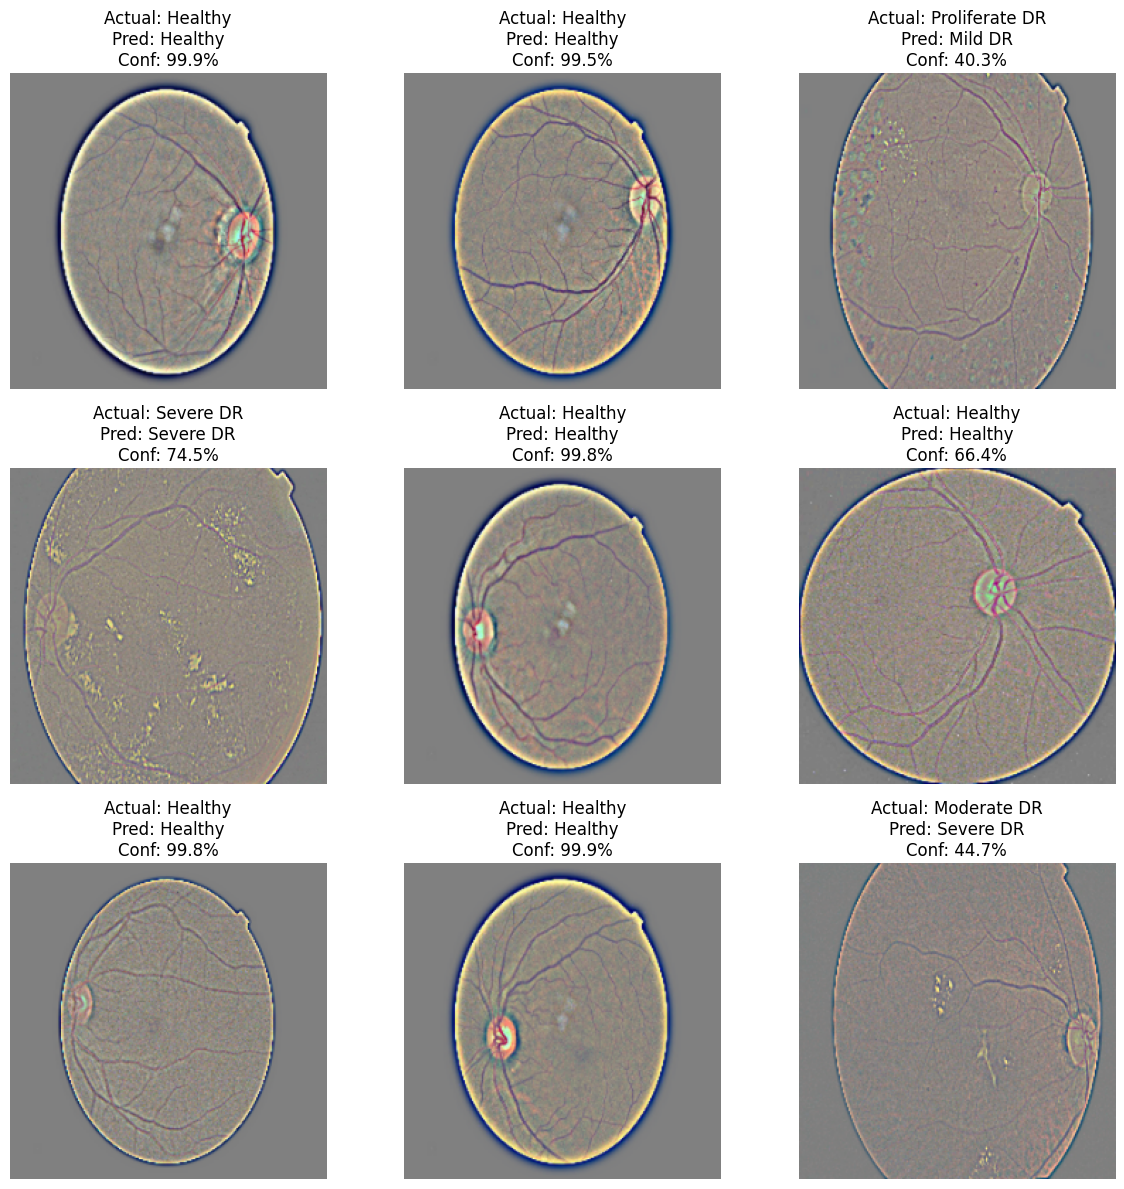

In [30]:
plt.figure(figsize=(12, 12))

for images, labels in val_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual_idx = np.argmax(
            labels[i].numpy()
        )

        predicted_idx = np.argmax(
            predictions[i]
        )

        confidence = (
            np.max(predictions[i]) * 100
        )

        actual_name = class_names[
            actual_idx
        ]

        predicted_name = class_names[
            predicted_idx
        ]

        plt.title(
            f"Actual: {actual_name}\n"
            f"Pred: {predicted_name}\n"
            f"Conf: {confidence:.1f}%"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
model.save(
    "DR_EfficientNetB0_Prototype.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [32]:
model = tf.keras.models.load_model(
    "DR_EfficientNetB0_Prototype.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [33]:
# Unfreeze the last part of EfficientNet
base_model.trainable = True

# Freeze most of the network
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 238
Trainable layers: 30


In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6750 - loss: 0.8941
Epoch 1: val_accuracy did not improve from 0.67636
69/69 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.6750 - loss: 0.8941 - val_accuracy: 0.6745 - val_loss: 0.8200 - learning_rate: 1.0000e-05
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6655 - loss: 0.8912
Epoch 2: val_accuracy did not improve from 0.67636
69/69 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6655 - loss: 0.8912 - val_accuracy: 0.6745 - val_loss: 0.8191 - learning_rate: 1.0000e-05
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.6705 - loss: 0.8955
Epoch 3: val_accuracy did not improve from 0.67636
69/69 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6705 - loss: 0.8955 - val_accuracy: 0.6745 - val_loss: 0.8195 - learning_rate: 1.0000e-05
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.6732 - loss: 0.8899
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 4: val

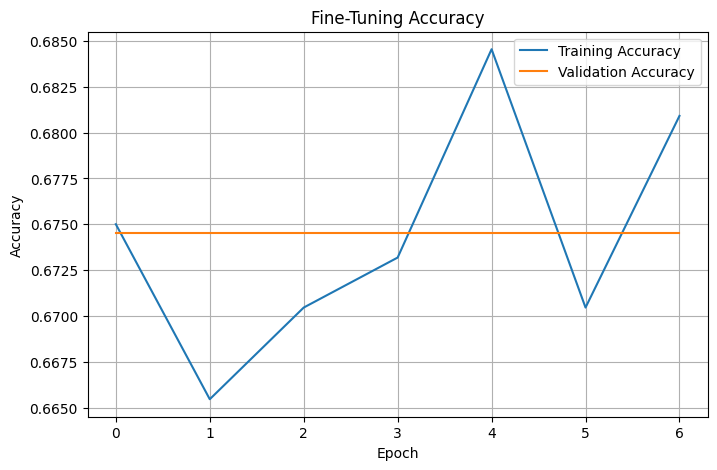

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                precision    recall  f1-score   support

       Healthy     0.9250    0.9737    0.9487       190
       Mild DR     0.6522    0.5696    0.6081        79
   Moderate DR     0.6141    0.6457    0.6295       175
Proliferate DR     0.3750    0.1053    0.1644        57
     Severe DR     0.2840    0.4694    0.3538        49

      accuracy                         0.6764       550
     macro avg     0.5701    0.5527    0.5409       550
  weighted avg     0.6728    0.6764    0.6639       550

